# Hotel Booking Cancellation Prediction

## Project Overview

The goal of this project is to analyze hotel booking data and build machine learning models to predict whether a booking will be canceled.

Hotel cancellations are important because they affect hotel revenue, room availability, staffing, and planning. If a hotel can predict which bookings are likely to be canceled, it can make better decisions about overbooking, customer follow-ups, and room management.

This project includes data cleaning, exploratory data analysis, cancellation pattern analysis, preprocessing, machine learning modeling, and model comparison.

## Import Libraries

First, I import the Python libraries needed for data analysis, visualization, preprocessing, modeling, and evaluation.

The main libraries used are:

- `pandas` and `numpy` for data handling
- `matplotlib` and `seaborn` for visualization
- `scikit-learn` for preprocessing, model building, and evaluation
- `xgboost` for the XGBoost classification model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier


import warnings
warnings.filterwarnings('ignore')

## Data Loading and Initial Inspection

In this section, I load the hotel booking dataset and inspect its basic structure. Before cleaning or modeling, it is important to understand the number of rows, columns, data types, missing values, and sample records.

Each row in the dataset represents a hotel booking, and the target variable is `is_canceled`.

- `0` means the booking was not canceled
- `1` means the booking was canceled

### Load the Dataset

The dataset is loaded into a pandas DataFrame. This allows us to inspect, clean, analyze, and model the data using Python.

In [2]:
df = pd.read_csv("data.csv")

### Basic Dataset Overview

I check the dataset shape, column names, and first few rows to understand what information is available.

The shape tells us how many rows and columns are in the dataset. The first few rows help verify that the data loaded correctly and give an initial look at the types of features included.

In [3]:
print("Columns: ", list(df.columns))
print("Shape: ", df.shape)

Columns:  ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']
Shape:  (119390, 32)


In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### Convert Date Column

The `reservation_status_date` column is converted to a datetime format. This is useful because dates stored as text are harder to analyze. Converting it to datetime makes it easier to work with date-based information if needed later.

However, this column will not be used for modeling because it can cause data leakage.

In [5]:
df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"])

### Data Types

I use `df.info()` to check the data types of each column and see whether any columns have missing values. This step helps identify which columns are numerical, categorical, or date-based.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119390 non-null  object        
 1   is_canceled                     119390 non-null  int64         
 2   lead_time                       119390 non-null  int64         
 3   arrival_date_year               119390 non-null  int64         
 4   arrival_date_month              119390 non-null  object        
 5   arrival_date_week_number        119390 non-null  int64         
 6   arrival_date_day_of_month       119390 non-null  int64         
 7   stays_in_weekend_nights         119390 non-null  int64         
 8   stays_in_week_nights            119390 non-null  int64         
 9   adults                          119390 non-null  int64         
 10  children                        119386 non-null  float64

### Missing Value Check

I check for missing values in the dataset. Missing values must be handled before modeling because most machine learning models cannot directly work with missing data.

The first check gives the total number of missing values, and the second check shows which columns contain missing values.

In [7]:
print("Total number of missing values:", df.isnull().sum().sum())
print("Number of rows with at least one missing value:", df.isnull().any(axis=1).sum())

Total number of missing values: 129425
Number of rows with at least one missing value: 119173


In [8]:
print(df.isnull().sum().sort_values(ascending=False))

company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations                 0
deposit_type    

### Handling Missing Values

The dataset has missing values in a few columns. I filled them based on what each column represents.

For `children`, missing values were filled with `0` because a missing value likely means no children were included in the booking.

For `country`, missing values were filled with `"Unknown"` because the customer country is not available.

For `company` and `agent`, missing values were filled with `0` because missing values likely mean the booking was not associated with a company or travel agent.

This step prepares the dataset for EDA and modeling.

In [9]:
df["children"] = df["children"].fillna(0)
df["country"] = df["country"].fillna("Unknown")
df["company"] = df["company"].fillna(0)
df["agent"] = df["agent"].fillna(0)

df["reservation_status_year"] = df["reservation_status_date"].dt.year
df["reservation_status_month"] = df["reservation_status_date"].dt.month
df["reservation_status_date_date"] = df["reservation_status_date"].dt.day

### Verify Missing Value Cleaning

After filling missing values, I check the dataset again to confirm that the missing values were handled successfully.

In [10]:
print("Missing values:\n", df.isnull().sum().sort_values(ascending=False))

Missing values:
 hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr        

## Exploratory Data Analysis

In this section, I explore the hotel booking data to understand cancellation patterns and relationships between features.

The main questions I want to answer are:

- Which countries have the most bookings?
- How does room price differ between hotel types?
- Which hotel type has more cancellations?
- Which room types are canceled more often?
- How does deposit type relate to cancellations?
- Do repeated guests cancel less often?
- How does cancellation behavior change by month?
- Which numerical features are related to cancellation?

EDA helps us understand the data before building machine learning models.

### Top Countries by Number of Bookings

This analysis shows the countries with the highest number of hotel bookings in the dataset. It helps identify where most customers are coming from.

Only the top 10 countries are shown to keep the visualization readable.

In [11]:
most_hotel_bookings = df["country"].value_counts().head(10)

Text(0, 0.5, 'Number of Bookings')

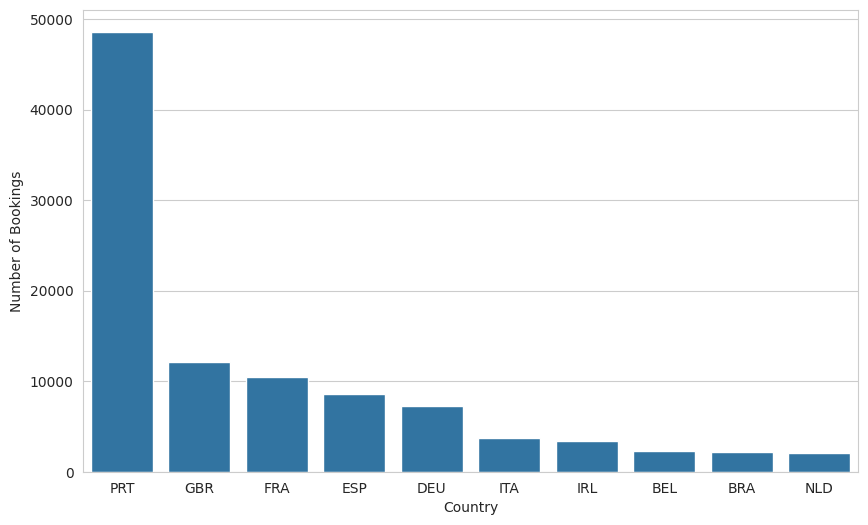

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(x=most_hotel_bookings.index, y=most_hotel_bookings.values)
plt.xlabel("Country")
plt.ylabel("Number of Bookings")

Most bookings come from a small number of countries. This suggests that customer origin may be an important feature because booking behavior and cancellation behavior may differ by country.

### Average Daily Rate by Hotel Type

The `adr` column represents the average daily rate, which is the price of the room per night.

This boxplot compares room prices between City Hotels and Resort Hotels. I limited the y-axis to reduce the effect of extreme outliers and make the main distribution easier to see.

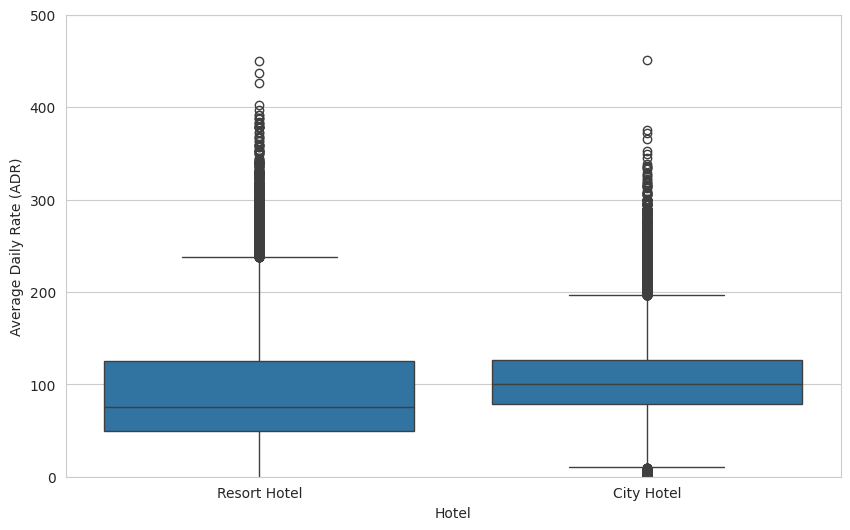

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="hotel", y="adr", data=df)
plt.xlabel("Hotel")
plt.ylabel("Average Daily Rate (ADR)")
plt.ylim(0, 500)
plt.show()

The plot shows how room prices differ between hotel types. Outliers exist in the ADR column, meaning some bookings have unusually high room prices. These outliers should be considered when interpreting price-based analysis.

### Cancellations by Reserved Room Type

This plot compares cancellations across reserved room types. It helps show whether certain room types are booked and canceled more often than others.

Because some room types appear much more frequently than others, this count plot shows volume, not cancellation rate.

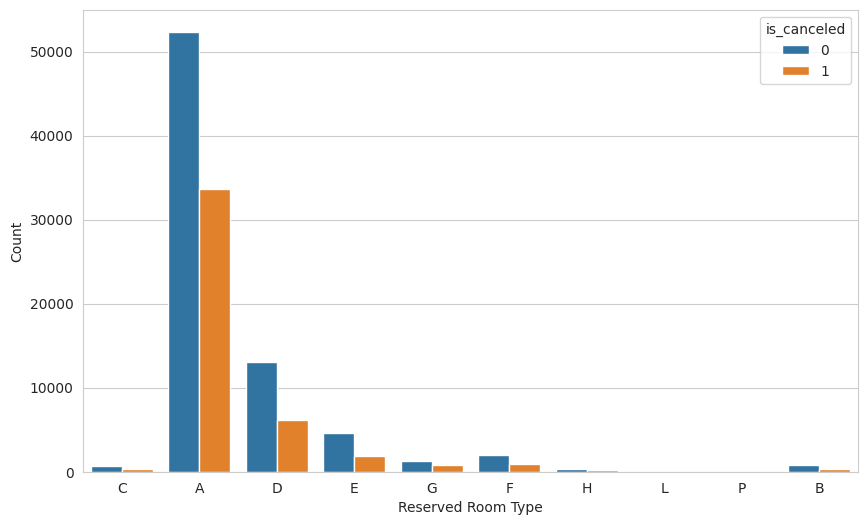

In [14]:
sns.countplot(data=df, x="reserved_room_type", hue="is_canceled")
plt.xlabel("Reserved Room Type")
plt.ylabel("Count")
plt.show()

Room type `A` appears most frequently in the dataset, so it also has the highest number of cancellations. However, this does not automatically mean room type `A` has the highest cancellation risk. To compare risk more fairly, cancellation rates should also be considered.

### Cancellations by Hotel Type

This plot compares the number of canceled and non-canceled bookings for each hotel type.

This helps show whether City Hotels and Resort Hotels have different cancellation patterns.

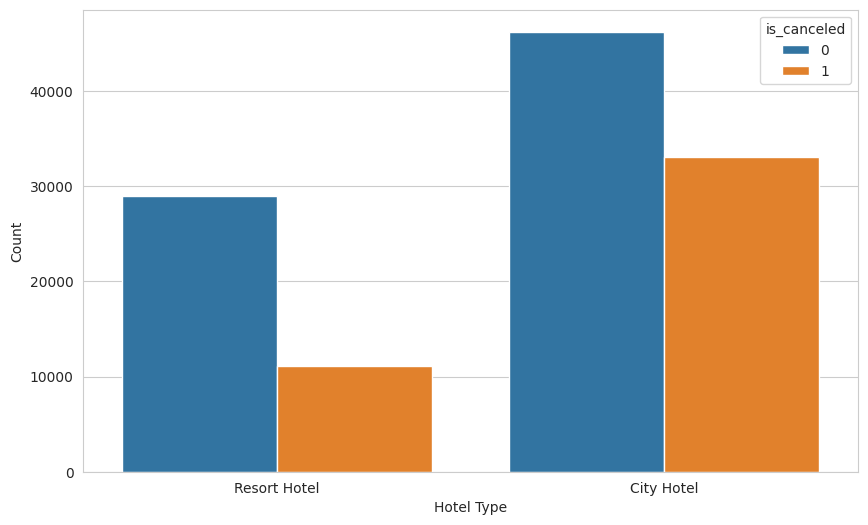

In [15]:
sns.countplot(data=df, x="hotel", hue="is_canceled")
plt.xlabel("Hotel Type")
plt.ylabel("Count")
plt.show()

City Hotel has more total bookings, so it also has more cancellations by count. However, count plots are affected by how many bookings each hotel type has overall. To understand cancellation risk more clearly, cancellation rate analysis is needed.

### Cancellations by Deposit Type

Deposit type may be strongly related to cancellation behavior because it affects customer commitment.

Customers with no deposit may find it easier to cancel, while customers with non-refundable deposits may behave differently. This plot helps compare cancellation counts across deposit types.

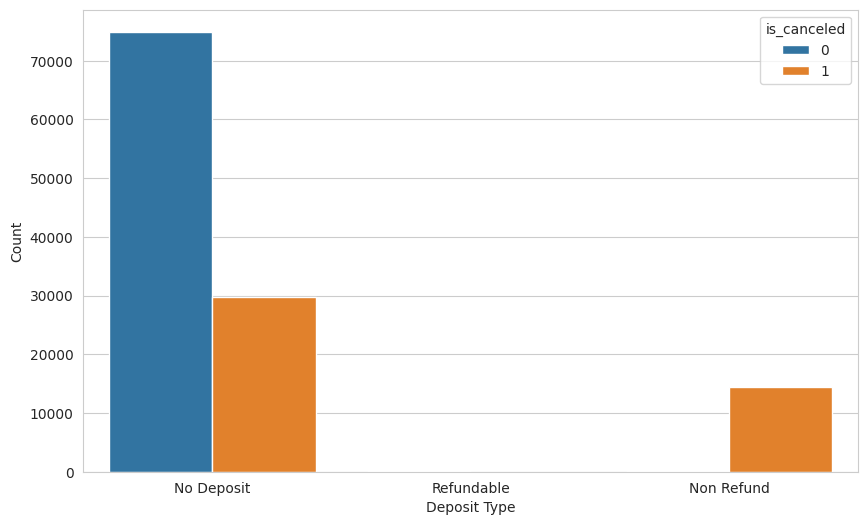

In [16]:
sns.countplot(data=df, x="deposit_type", hue="is_canceled")
plt.xlabel("Deposit Type")
plt.ylabel("Count")
plt.show()

Deposit type appears to be an important feature because cancellation behavior differs across deposit categories. This makes sense because the financial commitment of a deposit can affect whether a customer cancels.

### Cancellations by Assigned Room Type

This plot shows cancellations based on the room type that was actually assigned to the customer.

Comparing reserved room type and assigned room type can be useful because customers may not always receive the exact room type they originally reserved.

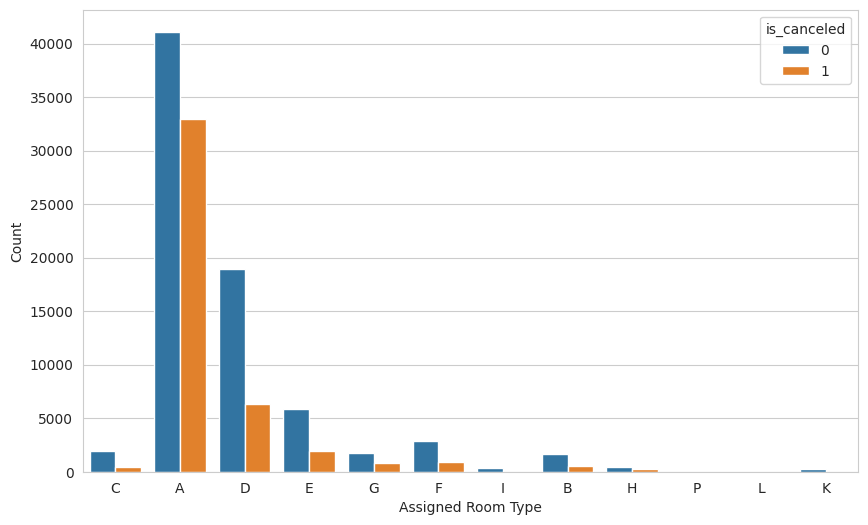

In [17]:
sns.countplot(data=df, x="assigned_room_type", hue="is_canceled")
plt.xlabel("Assigned Room Type")
plt.ylabel("Count")
plt.show()

### Reservation Status and Cancellation

This plot shows the relationship between reservation status and cancellation.

This column is useful for understanding the dataset, but it should not be used for modeling. `reservation_status` directly describes the final outcome of the booking, so including it in the model would cause data leakage.

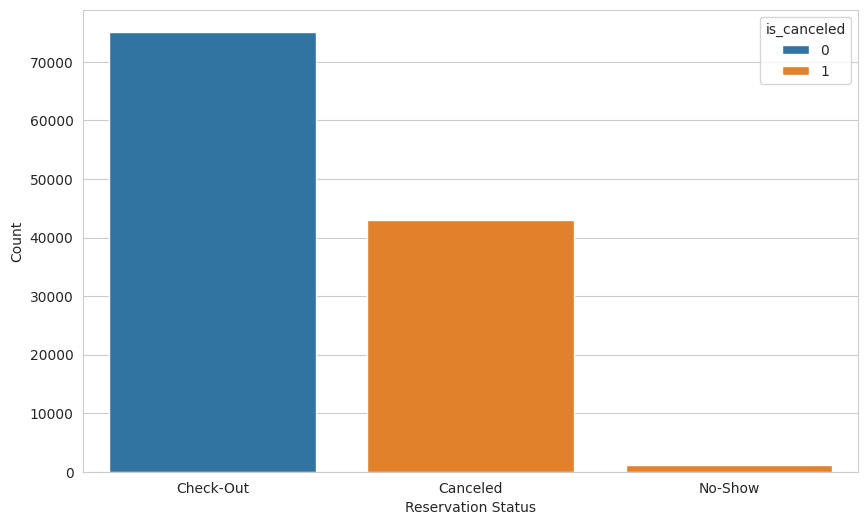

In [18]:
sns.countplot(data=df, x="reservation_status", hue="is_canceled")
plt.xlabel("Reservation Status")
plt.ylabel("Count")
plt.show()

The reservation status column is closely connected to the target variable. Because of this, it is removed before modeling to avoid data leakage.

### Resort Hotel Subset

I created a separate DataFrame for Resort Hotel bookings so that I can analyze pricing trends for resort hotels separately.

In [19]:
resort_df = df[df["hotel"] == "Resort Hotel"].copy()

In [20]:
resort_df_years_grouped_by_year = resort_df.groupby("arrival_date_year").agg({"adr": "mean"})

In [21]:
resort_df_years_grouped_by_year

,adr
arrival_date_year,
2015,89.353417
2016,87.730762
2017,108.660217


### Average ADR Over Time for Resort Hotels

This analysis groups Resort Hotel bookings by arrival year and calculates the average ADR for each year.

This helps show whether room prices changed over time for Resort Hotels.

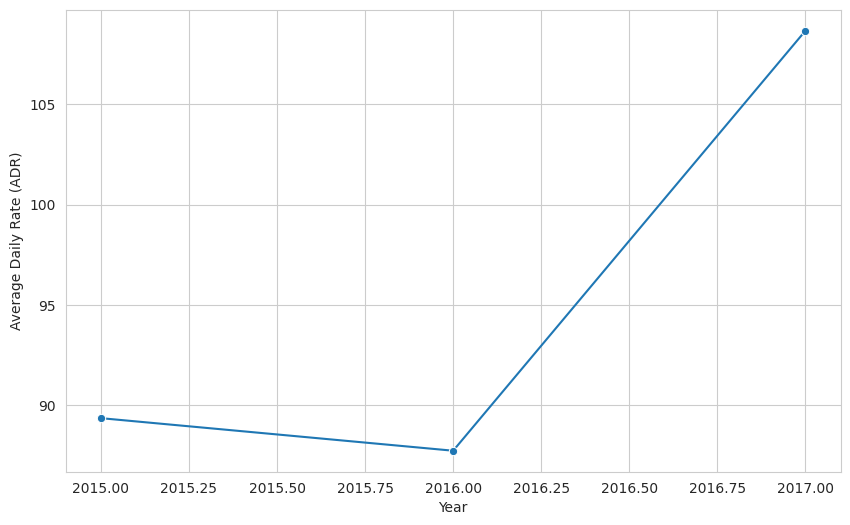

In [22]:
sns.lineplot(data=resort_df_years_grouped_by_year, x="arrival_date_year", y="adr", marker="o")

plt.xlabel("Year")
plt.ylabel("Average Daily Rate (ADR)")
plt.show()

The line plot shows the average daily rate trend for Resort Hotels from 2015 to 2017. Changes in ADR over time may reflect seasonal demand, pricing strategy, or changes in customer behavior.

### Average ADR Over Time for City Hotels

I repeat the same yearly ADR analysis for City Hotels. This allows comparison between City Hotels and Resort Hotels over time.

In [23]:
city_df = df[df["hotel"] == "City Hotel"].copy()

In [24]:
city_df_years_grouped_by_year = city_df.groupby("arrival_date_year").agg({"adr": "mean"})

city_df_years_grouped_by_year

,adr
arrival_date_year,
2015,85.856915
2016,103.483683
2017,117.501864


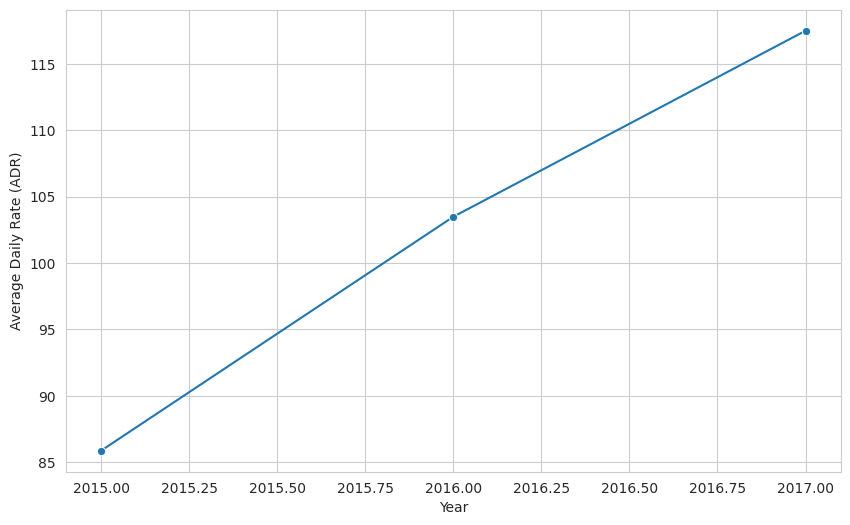

In [25]:
sns.lineplot(data=city_df_years_grouped_by_year, x="arrival_date_year", y="adr", marker="o")

plt.xlabel("Year")
plt.ylabel("Average Daily Rate (ADR)")
plt.show()

The City Hotel ADR trend shows how average room prices changed across the years in the dataset. Comparing this with Resort Hotels can reveal whether the two hotel types follow similar or different pricing patterns.

### Cancellations by Repeated Guest Status

This plot compares cancellation behavior between first-time guests and repeated guests.

Repeated guests may be less likely to cancel because they already have experience with the hotel and may be more loyal.

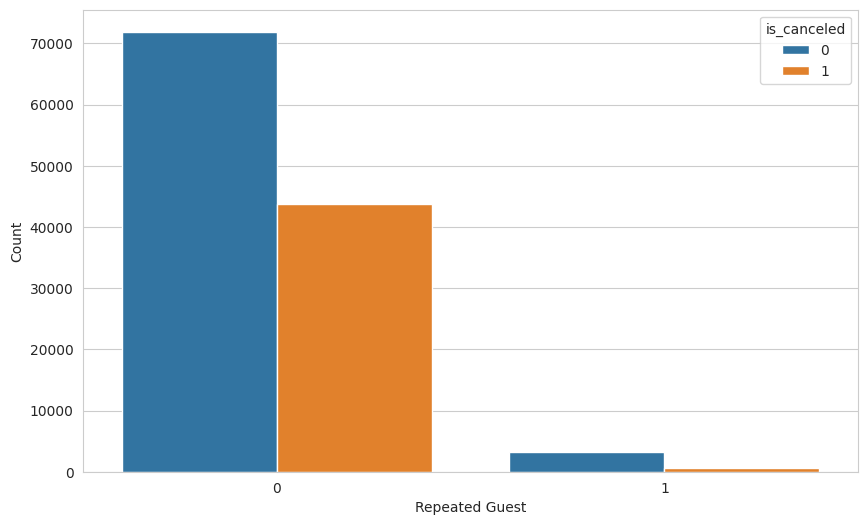

In [26]:
sns.countplot(data=df, x="is_repeated_guest", hue="is_canceled")
plt.xlabel("Repeated Guest")
plt.ylabel("Count")
plt.show()

Repeated guest status may be useful for prediction because returning customers can behave differently from new customers. If repeated guests cancel less often, this feature can help the model identify lower-risk bookings.

### Monthly Cancellation Patterns

This plot shows cancellations across arrival months. Monthly cancellation patterns are useful because hotel demand can change by season, holidays, and travel periods.

In this plot, I focus on City Hotel bookings to understand monthly cancellation behavior for that hotel type.

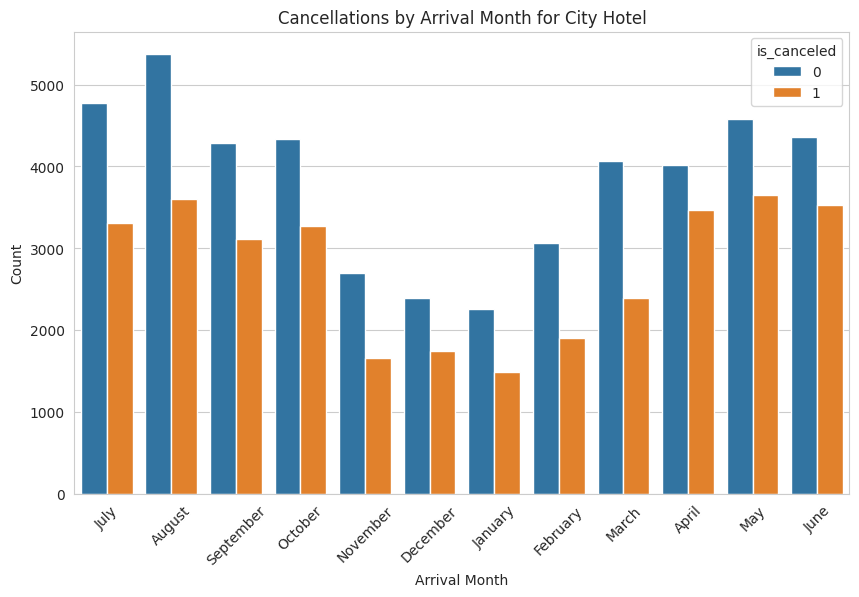

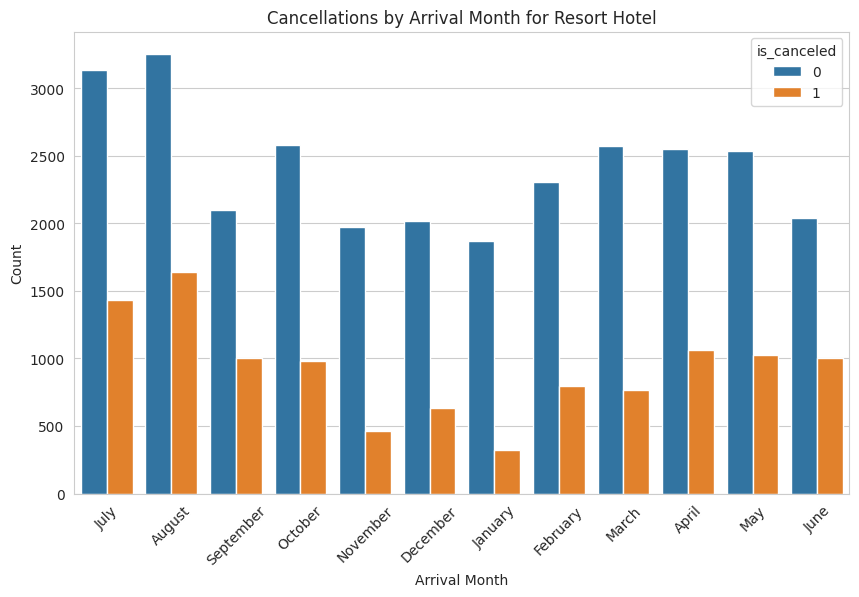

In [27]:
sns.countplot(data=city_df, x="arrival_date_month", hue="is_canceled")
plt.xlabel("Arrival Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.title("Cancellations by Arrival Month for City Hotel")
plt.show()

sns.countplot(data=resort_df, x="arrival_date_month", hue="is_canceled")
plt.xlabel("Arrival Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.title("Cancellations by Arrival Month for Resort Hotel")
plt.show()

Cancellation counts vary by month, which suggests that seasonality may play a role in booking behavior. However, this plot shows counts, so months with more bookings may naturally have more cancellations.

### Correlation Analysis

I use a correlation heatmap to examine relationships between important numerical features and the target variable `is_canceled`.

Correlation helps identify which numerical features move together. A positive correlation with `is_canceled` means the feature tends to increase when cancellations increase. A negative correlation means the feature tends to decrease when cancellations increase.

In [28]:
corr_columns = ['is_canceled', 'lead_time', 'arrival_date_month', 'stays_in_weekend_nights', 'stays_in_week_nights',
                'is_repeated_guest', 'previous_cancellations', 'days_in_waiting_list']

corr_cols_df = df[corr_columns]

corr_cols_df["arrival_month"] = corr_cols_df["arrival_date_month"].apply(lambda x: pd.to_datetime(x, format="%B").month)

corr_cols_df

,is_canceled,lead_time,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,is_repeated_guest,previous_cancellations,days_in_waiting_list,arrival_month
0,0,342,July,0,0,0,0,0,7
1,0,737,July,0,0,0,0,0,7
2,0,7,July,0,1,0,0,0,7
3,0,13,July,0,1,0,0,0,7
4,0,14,July,0,2,0,0,0,7
...,...,...,...,...,...,...,...,...,...
119385,0,23,August,2,5,0,0,0,8
119386,0,102,August,2,5,0,0,0,8
119387,0,34,August,2,5,0,0,0,8
119388,0,109,August,2,5,0,0,0,8


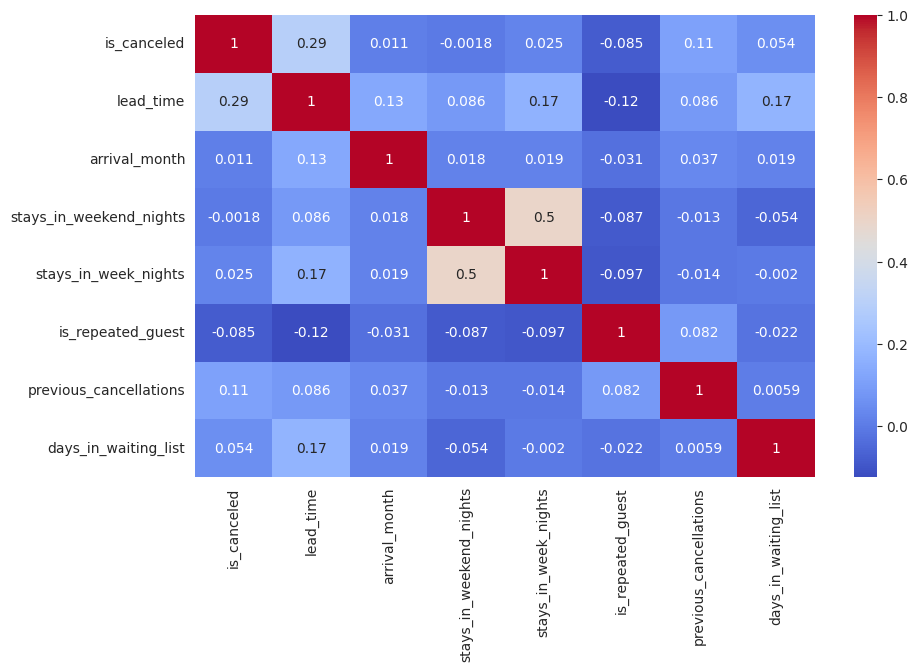

In [29]:
corr_cols_num = ['is_canceled', 'lead_time', 'arrival_month', 'stays_in_weekend_nights', 'stays_in_week_nights',
                'is_repeated_guest', 'previous_cancellations', 'days_in_waiting_list']

sns.heatmap(corr_cols_df[corr_cols_num].corr(), annot=True, cmap="coolwarm")
plt.show()

The correlation heatmap gives a quick overview of numerical relationships in the dataset. Features such as lead time, previous cancellations, booking changes, and waiting list days may have useful relationships with cancellation behavior.

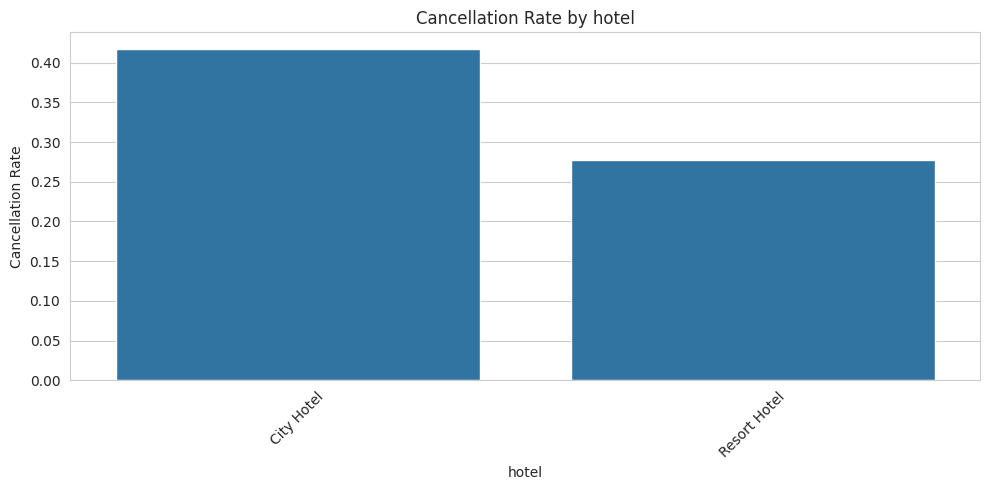

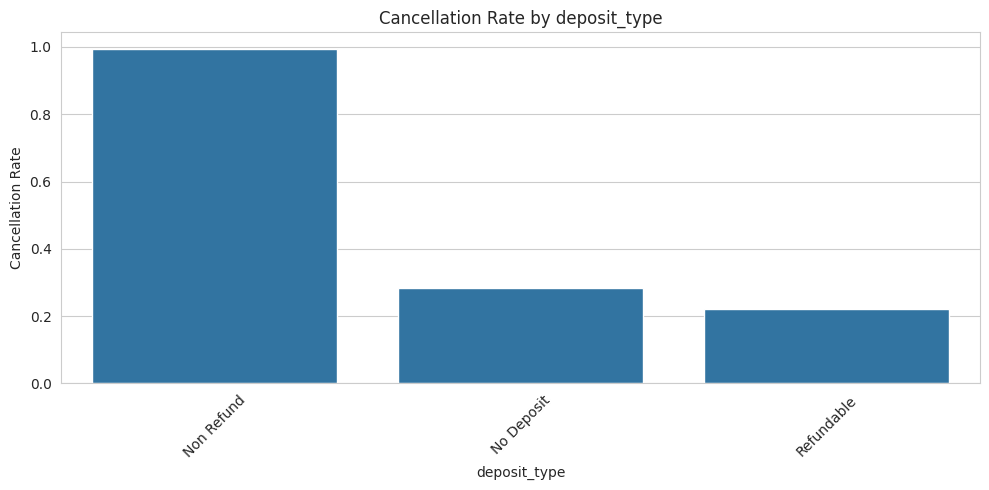

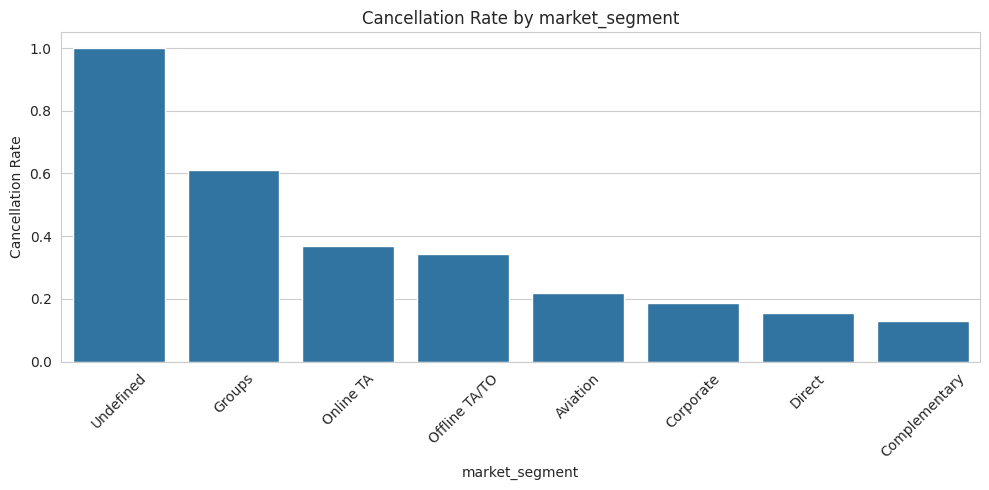

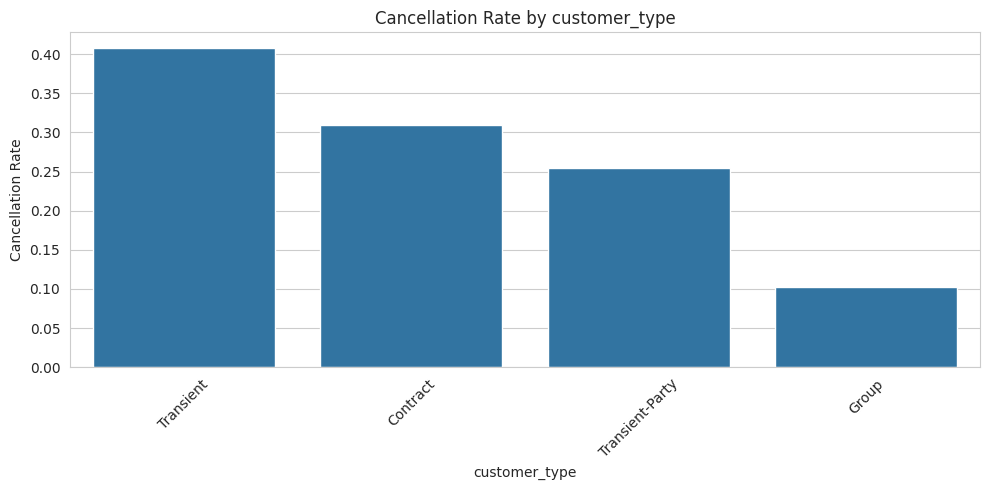

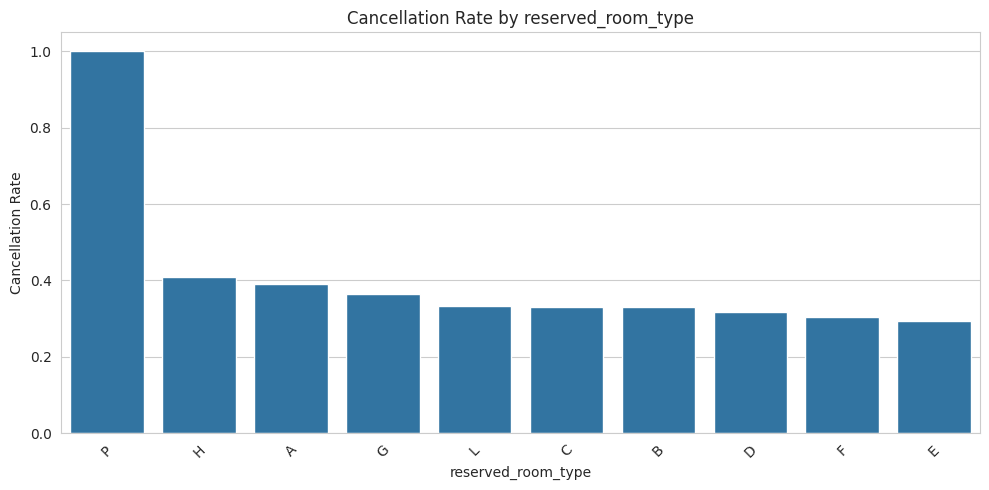

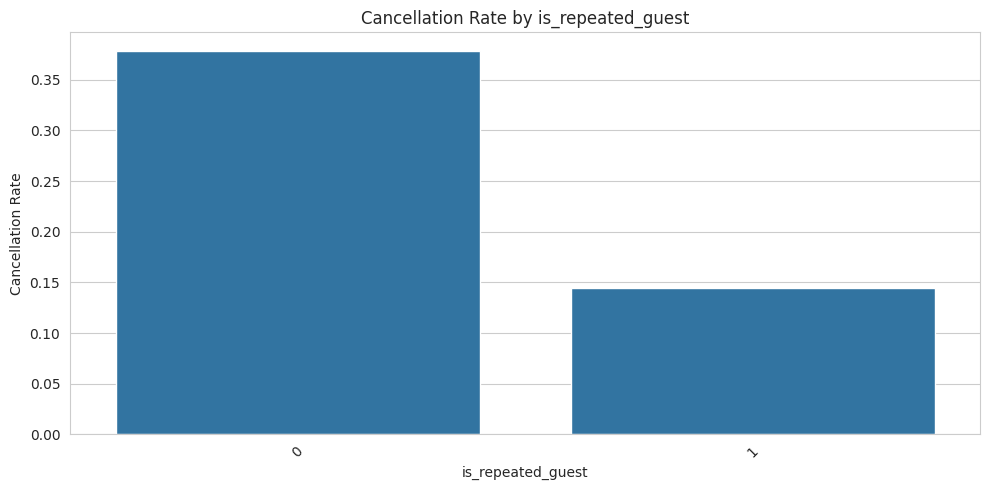

In [30]:
important_cat_cols = [
    "hotel",
    "deposit_type",
    "market_segment",
    "customer_type",
    "reserved_room_type",
    "is_repeated_guest"
]

for col in important_cat_cols:
    cancel_rate = df.groupby(col)["is_canceled"].mean().sort_values(ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=cancel_rate.index, y=cancel_rate.values)
    plt.title(f"Cancellation Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Cancellation Rate")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Cancellation Rate Analysis

Count plots show how many bookings belong to each category, but they do not always show which category has the highest cancellation risk. To understand cancellation risk better, I calculated the cancellation rate for important categorical columns.

The cancellation rate is the average of `is_canceled` for each group. Since `is_canceled` is 1 for canceled bookings and 0 for non-canceled bookings, the group mean represents the percentage of bookings that were canceled.

## Modeling

The goal of the modeling section is to predict whether a booking will be canceled.

This is a binary classification problem because the target variable `is_canceled` has two possible values:

- `0` = not canceled
- `1` = canceled

Before modeling, I remove `reservation_status` and `reservation_status_date` because they would cause data leakage. These columns describe the final outcome of the reservation, so they would give the model information that would not be available at the time of prediction.

### Train-Test Split

The data is split into training and testing sets.

The training set is used to train the models, while the testing set is used to evaluate how well the models perform on unseen data.

I use stratification so that the proportion of canceled and non-canceled bookings stays similar in both the training and testing sets.

In [31]:
X = df.drop(columns=["is_canceled", "reservation_status", "reservation_status_date"])
y = df["is_canceled"]

numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = X.select_dtypes(include=["object"]).columns

print("Numerical columns:", list(numerical_columns))
print("Categorical columns:", list(categorical_columns))

Numerical columns: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Preprocessing Pipeline

The dataset contains both numerical and categorical features, so preprocessing is needed before modeling.

For numerical columns, I use standard scaling so that numerical features are placed on a similar scale.

For categorical columns, I use one-hot encoding because machine learning models cannot directly understand text categories.

Using a pipeline keeps preprocessing and modeling organized and prevents mistakes during training and testing.

In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

### Logistic Regression

Logistic Regression is used as the baseline model.

It is a good first model for binary classification because it is simple, fast, and interpretable. The model predicts whether each booking will be canceled or not canceled.

The model is evaluated using accuracy, precision, recall, and F1 score.

In [34]:
logistic_model = Pipeline(
    steps=[
        ("preprocesser", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocesser',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_cha...
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [35]:
y_log_pred = logistic_model.predict(X_test)

print("Accuracy score:", accuracy_score(y_test, y_log_pred))
print("Precision score:", precision_score(y_test, y_log_pred))
print("Recall score:", recall_score(y_test, y_log_pred))
print("F1 score:", f1_score(y_test, y_log_pred))

Accuracy score: 0.8190384454309406
Precision score: 0.812
Recall score: 0.6655737704918033
F1 score: 0.7315315315315315


Logistic Regression provides a useful baseline. Since hotel cancellation prediction is not only about overall accuracy, I also consider precision, recall, and F1 score.

Recall is especially important because it tells us how many actual cancellations the model correctly identifies.

### Random Forest Classifier

Random Forest is a tree-based ensemble model. It builds many decision trees and combines their predictions.

This model can capture nonlinear relationships and interactions between features better than Logistic Regression. It may be useful for hotel cancellation prediction because cancellation behavior can depend on combinations of features such as lead time, deposit type, customer type, and market segment.

In [36]:
random_forest_model = Pipeline(
    steps=[
        ("preprocesser", preprocessor),
        ("model", RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42))
    ]
)

random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocesser',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_cha...
       'total_of_special_requests'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(max_depth=6, n_estimators=200,
                                        random_state=42))])

In [37]:
y_random_pred = random_forest_model.predict(X_test)

print("Accuracy score:", accuracy_score(y_test, y_random_pred))
print("Precision score:", precision_score(y_test, y_random_pred))
print("Recall score:", recall_score(y_test, y_random_pred))
print("F1 score:", f1_score(y_test, y_random_pred))

Accuracy score: 0.7654744953513695
Precision score: 0.9984639016897081
Recall score: 0.36743923120407007
F1 score: 0.5371900826446281


Random Forest is useful because it can model more complex patterns. However, its performance should be judged using recall and F1 score, not accuracy alone.

### Decision Tree Classifier

A Decision Tree model is also tested.

Decision Trees make predictions by splitting the data based on feature values. They are easy to understand, but a single decision tree can sometimes overfit the training data.

I limit the tree depth to reduce overfitting and compare it against the other models.

In [38]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocesser", preprocessor),
        ("model", DecisionTreeClassifier(max_depth=6, random_state=42))
    ]
)

decision_tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocesser',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_cha...
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type'],
      dtype='object'))])),
                ('model',
                 DecisionTreeClassifier(max_depth=6, random_state=42))])

In [39]:
y_decision_pred = decision_tree_model.predict(X_test)

print("Accuracy score:", accuracy_score(y_test, y_decision_pred))
print("Precision score:", precision_score(y_test, y_decision_pred))
print("Recall score:", recall_score(y_test, y_decision_pred))
print("F1 score:", f1_score(y_test, y_decision_pred))

Accuracy score: 0.8180333361253036
Precision score: 0.7955859169732002
Recall score: 0.684680610514415
F1 score: 0.735978610925442


The Decision Tree gives another baseline for comparison. It is more flexible than Logistic Regression, but usually less powerful than ensemble methods like Random Forest or XGBoost.

### XGBoost Classifier

XGBoost is a boosting-based tree model. It builds trees sequentially, where each new tree tries to correct the mistakes of the previous trees.

XGBoost often performs well on structured tabular datasets, so it is a strong model choice for this hotel cancellation prediction problem.

In [40]:
xb_model = Pipeline(
    steps=[
        ("preprocesser", preprocessor),
        ("model", XGBClassifier(n_estimators=200, max_depth=6, random_state=42))
    ]
)

xb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocesser',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_cha...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [41]:
y_xb_pred = xb_model.predict(X_test)

print("Accuracy score:", accuracy_score(y_test, y_xb_pred))
print("Precision score:", precision_score(y_test, y_xb_pred))
print("Recall score:", recall_score(y_test, y_xb_pred))
print("F1 score:", f1_score(y_test, y_xb_pred))

Accuracy score: 0.8851662618309741
Precision score: 0.8618522471243922
Recall score: 0.8217071791972866
F1 score: 0.8413010765134854


XGBoost is expected to perform well because it can capture complex relationships between booking features and cancellation outcomes.

### Model Comparison Table

After training all models, I compare their performance using accuracy, precision, recall, and F1 score.

Accuracy shows overall correctness, but it is not enough by itself. Precision and recall are important because they explain how well the model handles canceled bookings specifically.

F1 score is especially useful because it balances precision and recall.

In [42]:
scores_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Decision Tree", "XGBoost"],
    "Accuracy": [accuracy_score(y_test, y_log_pred), accuracy_score(y_test, y_random_pred), accuracy_score(y_test, y_decision_pred), accuracy_score(y_test, y_xb_pred)],
    "Precision": [precision_score(y_test, y_log_pred), precision_score(y_test, y_random_pred), precision_score(y_test, y_decision_pred), precision_score(y_test, y_xb_pred)],
    "Recall": [recall_score(y_test, y_log_pred), recall_score(y_test, y_random_pred), recall_score(y_test, y_decision_pred), recall_score(y_test, y_xb_pred)],
    "F1 Score": [f1_score(y_test, y_log_pred), f1_score(y_test, y_random_pred), f1_score(y_test, y_decision_pred), f1_score(y_test, y_xb_pred)]
})

In [43]:
scores_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.819038,0.812000,0.665574,0.731532
1,Random Forest,0.765474,0.998464,0.367439,0.537190
2,Decision Tree,0.818033,0.795586,0.684681,0.735979
3,XGBoost,0.885166,0.861852,0.821707,0.841301


### Model Comparison Results

I compared Logistic Regression, Random Forest, Decision Tree, and XGBoost for predicting hotel booking cancellations.

XGBoost performed the best overall. It had the highest accuracy, highest recall, and highest F1 score among the models tested. This means XGBoost was the best at balancing correct cancellation predictions with identifying actual canceled bookings.

Logistic Regression and Decision Tree performed reasonably well and served as useful baseline models. However, they did not capture the complex patterns in the data as well as XGBoost.

Random Forest had very high precision but much lower recall. This means that when Random Forest predicted a cancellation, it was usually correct, but it missed many actual cancellations. Because of this, Random Forest was not the best model for this specific problem.

Overall, XGBoost was selected as the best model because it achieved the strongest balance of accuracy, recall, and F1 score.

### Visual Model Comparison

The bar plots below compare the models across accuracy, precision, recall, and F1 score.

Visualizing the metrics makes it easier to see which model performs best overall and where each model has strengths or weaknesses.

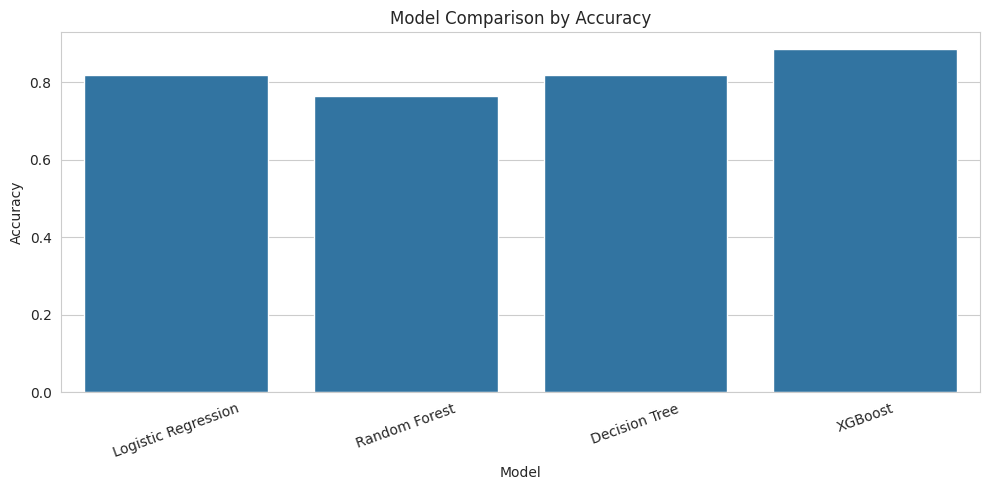

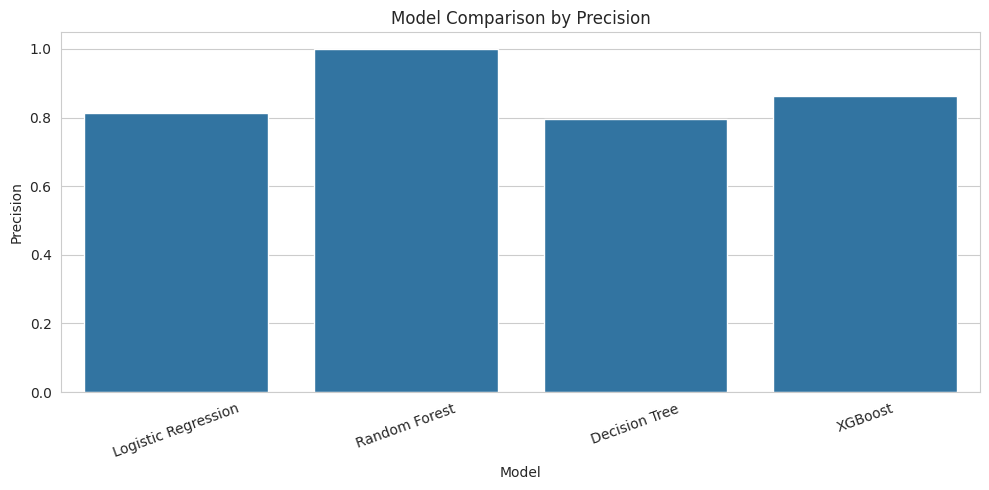

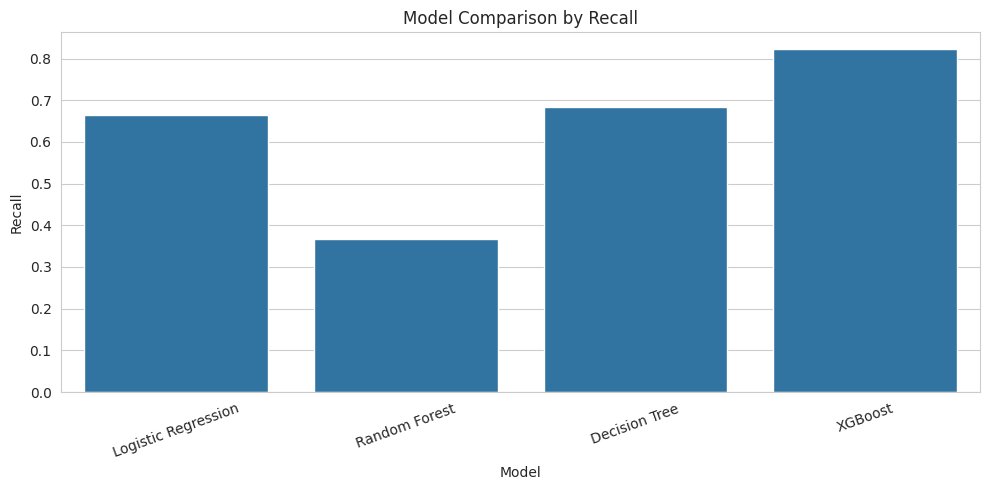

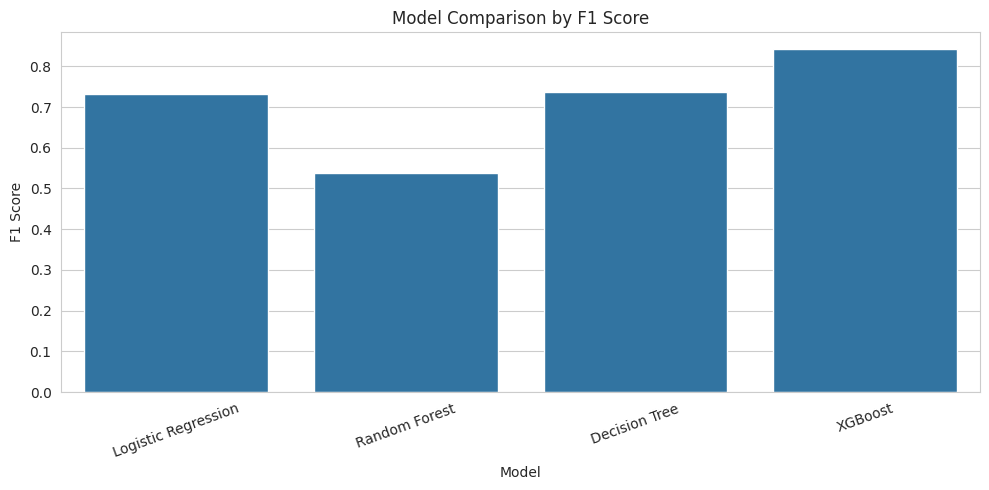

In [44]:
cols = ["Accuracy", "Precision", "Recall", "F1 Score"]

for col in cols:
  plt.figure(figsize=(10, 5))
  sns.barplot(data=scores_df, x="Model", y=col)
  plt.title(f"Model Comparison by {col}")
  plt.xlabel("Model")
  plt.ylabel(col)
  plt.xticks(rotation=20)
  plt.tight_layout()
  plt.show()

### Visual Model Comparison

The bar plots below compare the models across accuracy, precision, recall, and F1 score.

Visualizing the metrics makes it easier to see which model performs best overall and where each model has strengths or weaknesses.

## Limitations and Future Improvements

Although the model performed well, there are still limitations.

First, the dataset may not include all real-world factors that affect cancellations, such as customer personal reasons, competitor prices, weather, local events, or flight disruptions.

Second, the model was evaluated using a random train-test split. In a real hotel setting, a time-based split may be more realistic because future bookings should be predicted using past data.

Third, the models were trained mostly with default or simple hyperparameters. Performance could potentially improve with hyperparameter tuning.

Future improvements could include:

- Hyperparameter tuning for XGBoost
- Feature importance analysis
- Time-based validation
- Additional feature engineering
- Handling class imbalance more carefully
- Building a dashboard to visualize cancellation risk